<a href="https://colab.research.google.com/github/HanTanto/general_insurance/blob/main/Modifikasi_besar_klaim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Hani Tustanto

NIM : 20924005


---



---



# **1. PENDAHULUAN**

Pada tugas ini, penulis akan mengeksplorasi distribusi untuk kerugian dan juga modifikasi terhadap distribusi tersebut meliputi *deductible*, *policy limit*, dan *coinsurance*. Data yang akan digunakan yaitu data klaim asuransi rawat inap suatu perusahaan asuransi yang diperoleh dari kaggle [link dataset](https://www.kaggle.com/code/kerneler/starter-insurance-claim-dataset-efa06de4-6/input). Data tersebut akan digunakan untuk memperdalam distribusi kerugian. Misalkan $X$ merupakan peubah acak besar kerugian dari asuransi rawat inap dalam dolar. Dari distribusi $X$ akan dilakukan modifikasi dan setiap modifikasi akan dicari nilai dari
1. Fungsi distribusi
2. Ekspektasi dan variansi
3. Fungsi kuanti
4. Pembangkitan sampel acak





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, pareto, expon, weibull_min, lognorm
data = pd.read_csv('Data.csv')

In [ ]:
klaim = data['CLM_PMT_AMT']
klaim = klaim[klaim>0]
pd.DataFrame(klaim.describe()).T

,count,mean,std,min,25%,50%,75%,max
CLM_PMT_AMT,64558.0,9902.625856,9299.638288,10.0,4000.0,7000.0,11000.0,57000.0


Besar kerugian $X$ memiliki rata-rata sebesar 9299 dengan standar deviasi sebesar 9902. Memiliki nilai minimal 10, median 7000, dan maksimal 57000. Sehingga distribusi $X$ akan pada dikiri dengan ekornya kanan yang cukup tebal.

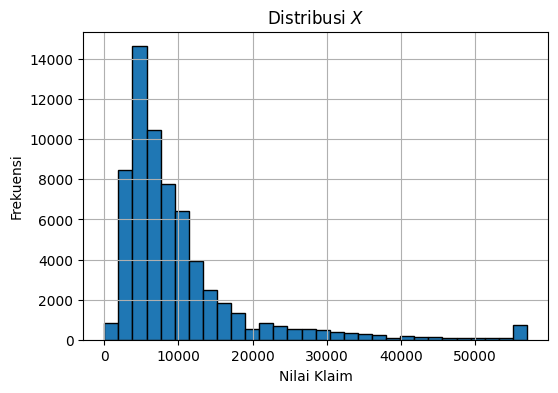

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(klaim, bins=30, edgecolor='black')
plt.xlabel('Nilai Klaim')
plt.ylabel('Frekuensi')
plt.title('Distribusi $X$')
plt.grid(True)
plt.show()

Fitted gamma parameters: (1.7975395938844783, 0, np.float64(5508.989003363216))
RMSE 3.1502146309396514e-05
Fitted weibull_min parameters: (np.float64(1.2641992057207965), 0, np.float64(10770.033860230295))
RMSE 1.8064000211807563e-05
Fitted lognorm parameters: (np.float64(0.7710785466718307), 0, np.float64(7312.2989089825))
RMSE 6.7448010812892425e-06


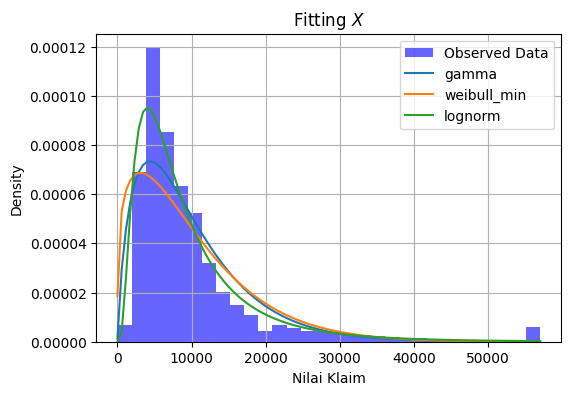

In [ ]:
# @title Default title text
dist_name = [gamma,   weibull_min, lognorm]
dist_names = ['gamma', 'weibull_min', 'lognorm']
dist_params = {}

counts, bin_edges = np.histogram(klaim, bins=30, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
for i in range (len(dist_name)):
  params = dist_name[i].fit(klaim, floc =0)
  dist_params[dist_names[i]] = params
  pdf_fitted = lognorm.pdf(bin_centers, *params)
  print(f"Fitted {dist_names[i]} parameters: {params}")
  print(f'RMSE {(np.mean((counts - pdf_fitted) ** 2))**0.5}')

# Create the histogram again for comparison
plt.figure(figsize=(6,4))
plt.hist(klaim, bins=30, density=True, alpha=0.6, color='b', label='Observed Data')

# Plot fitted distributions
x = np.linspace(klaim.min(), klaim.max(), 100)

for dist in dist_names:
  pdf = getattr(globals()[dist], 'pdf')(x, *dist_params[dist])
  plt.plot(x, pdf, label=dist)


plt.xlabel('Nilai Klaim')
plt.ylabel('Density')
plt.title('Fitting $X$')
plt.legend()
plt.grid(True)
plt.show()


Berdasarkan hasil *fitting*, model yang paling sesuai dengan data klaim yaitu lognormal dengan RMSE sebesar $6.7x10^{-6}$. Untuk memvalidasi hasil ini, akan digunakan uji Kologorov-smirnov, apakah model lognormal sesuai dengan data atau tidak. Hipotesis yang digunakan yaitu

$H_0$ : Data berasal dari distribusi lognormal

$H_1$ : Data tidak berasal dari distribusi lognormal

In [ ]:
# @title Uji hipotesis
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Contoh: Data lognormal buatan
np.random.seed(0)
data = np.random.lognormal(mean=np.log(7312.2989), sigma=0.7711, size=100)

# Estimasi parameter lognormal (ingat: scipy pakai parameter shape, loc, scale)
shape, loc, scale = stats.lognorm.fit(data, floc=0)  # floc=0 jika yakin tidak ada offset

# Lakukan uji Kolmogorov-Smirnov
ks_stat, p_value = stats.kstest(data, 'lognorm', args=(shape, loc, scale))

print(f"Hasil Uji K-S:")
print(f"  Statistik KS = {ks_stat:.4f}")
print(f"  p-value = {p_value:.4f}")

# Simpulan
alpha = 0.05
if p_value > alpha:
    print("Kesimpulan: Gagal tolak H0. Data kemungkinan berasal dari distribusi lognormal.")
else:
    print("Kesimpulan: Tolak H0. Data kemungkinan TIDAK berasal dari distribusi lognormal.")


Hasil Uji K-S:
  Statistik KS = 0.0636
  p-value = 0.7894
Kesimpulan: Gagal tolak H0. Data kemungkinan berasal dari distribusi lognormal.


Dari hasil di atas, dengan mengambil selang kepercayaan $95\%$, diperoleh bahwa $H_0$ gagal ditolak. Sehingga, data dapat dikatakan mengikuti distribusi lognormal. Fungsi peluang $X$ berdistribusi lognormal dengan parametr $\mu = log(7312.2989)$ dan $\sigma = 0.7711$. Fungsi peluang dari $X\sim Lognormal(log(\mu), \sigma)$ yaitu
\begin{align}
f(x)=\frac{1}{x\cdot \sigma\sqrt{2\pi}}exp\bigg( -\frac{(log(x)-\mu)^2}{2\sigma^2}\bigg)
\end{align}

Dengan kata lain $log(X)=Y \sim normal(\mu, \sigma^2)$

In [ ]:
mu = np.log(7312.2989)
s = 0.7711

Perhatikan bahwa
\begin{align}
E[X^k]&=E[e^{kY}] \\
&= \int_{-\infty}^\infty e^{ky} f_Y(y) dy \\
&= \int_{-\infty}^\infty e^{ky} \frac{1}{ \sigma\sqrt{2\pi}}exp\bigg( -\frac{(y-\mu)^2}{2\sigma^2}\bigg) dy \\
&= \int_{-\infty}^\infty \frac{1}{ \sigma\sqrt{2\pi}}exp\bigg( -\frac{(y-\mu)^2}{2\sigma^2}+ky\bigg) dy\\
&=\int_{-\infty}^\infty \frac{1}{ \sigma\sqrt{2\pi}}exp\bigg( -\frac{y^2-2y\mu+\mu^2-2ky\sigma^2}{2\sigma^2}\bigg) dy\\
&=\int_{-\infty}^\infty \frac{1}{ \sigma\sqrt{2\pi}}exp\bigg( -\frac{y^2-2(\mu+k\sigma^2)y+\mu^2}{2\sigma^2}\bigg) dy\\
&=\int_{-\infty}^\infty \frac{1}{ \sigma\sqrt{2\pi}}exp\bigg( -\frac{(y-\mu-k\sigma^2)^2-(\mu+k\sigma^2)^2+\mu^2}{2\sigma^2}\bigg) dy\\
&= \int_{-\infty}^\infty \frac{1}{ \sigma\sqrt{2\pi}}exp\bigg( -\frac{(y-\mu-k\sigma^2)^2-2k\mu\sigma^2-k^2\sigma^4}{2\sigma^2}\bigg) dy\\
&= exp(k\mu+\frac{k^2\sigma^2}{2})\int_{-\infty}^\infty \frac{1}{ \sigma\sqrt{2\pi}}exp\bigg( -\frac{(y-\mu-k\sigma^2)^2}{2\sigma^2}\bigg) dy\\
&=exp\bigg(k\mu+\frac{k^2\sigma^2}{2}\bigg)
\end{align}

# **2. Pemodelan**

## **A. Deductible**

Misalkan $X$ merupakan peubah acak kerugian yang telah diperoleh sebelumnya.
\begin{align}
X_L = (X-d)_+ = \begin{cases}0 & , x\le d \\ X-d &, x >d \end{cases}
\end{align}

### **A1. Fungsi Distribusi**

**Akan dicari fungsi distribusi dari $X$**
\begin{align}
P(X_L \le x) &= P(X_L\le x|X\le d)\cdot P(X\le d)+P(X_L\le x|X>d)\cdot P(X>d) \\
&= P(0\le x|X\le d)\cdot P(X\le d)+P(X-d\le x|X>d)\cdot P(X>d) \\
&= P(X\le d)+\frac{P(X-d\le x,X>d)}{P(X>d)}\cdot P(X>d) \\
&=P(X\le d)+[P(X\le x+d)-P(X\le d)]
\end{align}
Diperoleh

Untuk $ln(X) = Y \sim normal (\mu, \sigma^2)$ perhatikan bahwa
\begin{align}
P(X\le x)&=P(ln(X)\le ln(x)) \\
&= P(Y \le ln(x)) \\
&= P\bigg(\frac{Y-\mu}{\sigma} \le \frac{ln(x)-\mu}{\sigma}\bigg) \\
&= P\bigg(Z\le \frac{ln(x)-\mu}{\sigma}\bigg) \\
&= \phi\bigg(\frac{ln(x)-\mu}{\sigma}\bigg)
\end{align}

Dengan $Z=\frac{Y-\mu}{\sigma}\sim Normal(0,1)$ dan $\phi(a)=P(Z\le a)$
Diperoleh
\begin{align}
P(X_L \le x) = \begin{cases} 0 &, x< 0 \\\phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg) & , x=0 \\ \phi\bigg(\frac{ln(x+d)-\mu}{\sigma}\bigg) &, x>0 \end{cases}
\end{align}
Fungsi peluangnya yaitu
\begin{align}
f_{X_L}(x) = \begin{cases} \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg) & , x=0 \\ f_X(x+d) &, x>0 \\ 0 & , x \ lainnya \end{cases}
\end{align}

In [ ]:
# @title Default title text
from scipy.stats import norm
def phi(x):
  return norm.cdf(x)
def phi_inv(p):
  return norm.ppf(p)
#Fungsi distribusi
def F_deductible(x,d):
  if x==0:
    return phi((np.log(d)-mu)/s)
  else:
    return phi((np.log(x+d)-mu)/s)
# Ekspektasi dan Variansi
def Ek(x,k):
  return np.exp(k*mu+k**2*s**2/2)*(1-phi((np.log(x)-mu-k*s**2)/s))
def Exp_deductible(d):
  return Ek(d,1)-d*(1-phi((np.log(d)-mu)/s))
def Exp2_deductible(d):
  return Ek(d,2)-2*d*Ek(d,1)+(d**2)*(1-phi((np.log(d)-mu)/s))
def Var_deductible(d):
  return Exp2_deductible(d)-Exp_deductible(d)**2
# Fungsi kuantil dan membangkitkan sampel acak
def q_L(p,d):
  if p<=phi((np.log(d)-mu)/s):
    return 0
  else:
    return np.exp(mu+s*phi_inv(p))-d
def X_L(n,d):
  p = np.random.uniform(0,1,n)
  XL = []
  for i in range(n):
    if p[i]<=phi((np.log(d)-mu)/s):
      XL.append(0)
    else:
      XL.append(np.exp(mu+s*phi_inv(p[i]))-d)
  return np.array(XL)

def Plot1(x,fun,tit, lbl=['Nilai Klaim','Density'],d=2000, con=0):
  FD = [fun(x[i], d) for i in range(len(x))]
  plt.figure(figsize=(6, 4))

  plt.plot(x, FD, '.', markersize=2)
  plt.xlabel(f'{lbl[0]}')
  plt.ylabel(f'{lbl[1]}')
  if con==0:
    plt.title(f'Plot {tit} $X_L$ dengan $d={d}$')
  elif con==2:
    plt.title(f'Plot {tit} $X_c$ dengan $c={d}$')
  else:
    plt.title(f'Plot {tit} $X_u$ dengan $u={d}$')
  plt.grid(True)
  plt.show()

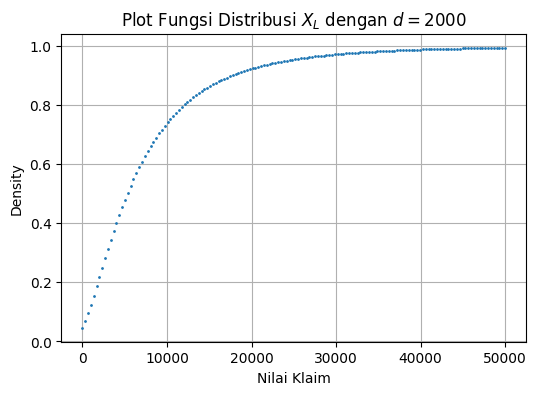

In [ ]:
x = np.linspace(0, 50000, 150)
Plot1(x,F_deductible, 'Fungsi Distribusi')

Fungsi distribusi dengan deductible $d=2000$, niali $X=0$ cukup banyak sehingga peluangnya tidak nol.

### **A2. Ekspektasi dan variansi**

**Akan dicari ekspektasi dari $X_L$**
\begin{align}
E[X_L] &= E[X-d \mid X>d]\cdot P(X>d) \\
&=E[X \mid X>d]\cdot P(X>d)-d\cdot P(X>d) \\
&= E[e^Y \mid e^Y > d] \cdot P(x>d)-d\cdot P(X>d) \\
&= E[e^Y \mid Y>ln(d)] \cdot P(X>d)-d\cdot P(X>d) \\
& = \frac{\int_{ln(d)}^{\infty} e^Y f_Y(y) dy}{P(X>d)}\cdot P(X>d)-d\cdot(X>d) \\
&= \int_{ln(d)}^{\infty} e^Y f_Y(y) dy-d\cdot P(X>d)
\end{align}

Perhatikan bahwa
\begin{align}
\int_{a}^{\infty} e^{kY}f_Y(y) dy &= exp(k\mu+\frac{k^2\sigma^2}{2})\int_{a}^\infty \frac{1}{ \sigma\sqrt{2\pi}}exp\bigg( -\frac{(y-\mu-k\sigma^2)^2}{2\sigma^2}\bigg) dy\\
\end{align}
Dengan memilih $Z=\dfrac{Y-\mu-k\sigma^2}{\sigma}$ diperoleh
\begin{align}
\int_{a}^{\infty} e^{kY}f_Y(y) dy &= exp(k\mu+\frac{k^2\sigma^2}{2})\int_{\frac{a-\mu-k\sigma^2}{\sigma}}^\infty \frac{1}{ \sqrt{2\pi}}exp\bigg( -\frac{z^2}{2}\bigg) dz\\
&= exp(k\mu+\frac{k^2\sigma^2}{2})\cdot \bigg[1-\phi\bigg(\frac{a-\mu-k\sigma^2}{\sigma}\bigg)\bigg]
\end{align}
Sehingga
\begin{align}
E[X_L]=exp(\mu+\frac{\sigma^2}{2})\cdot \bigg[1-\phi\bigg(\frac{ln(d)-\mu-\sigma^2}{\sigma}\bigg)\bigg]-d \cdot\bigg[1- \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg)\bigg]
\end{align}

**Akan dicari variansi dari X_L**
\begin{align}
E[X_L^2] &= E[(X-d)^2 \mid X>d]\cdot P(X>d) \\
&= E[X^2-2dX+d^2\mid X>d]\cdot P(X>d) \\
&=(E[X^2\mid X>d]-2dE[X\mid X>d])P(X>d)+d^2P(X>d) \\
&=(E[e^{2Y}\mid Y>ln(d)]-2dE[e^{Y}\mid Y>ln(d)])P(Y>ln(d))+d^2P(X>d) \\
&=exp(\mu+2\sigma^2)\cdot \bigg[1-\phi\bigg(\frac{ln(d)-\mu-2\sigma^2}{\sigma}\bigg)\bigg]-2d\cdot exp(\mu+\frac{\sigma^2}{2})\cdot \bigg[1-\phi\bigg(\frac{ln(d)-\mu-\sigma^2}{\sigma}\bigg)\bigg] \\ & +d^2 \cdot \bigg[1-\phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg)\bigg]
\end{align}
Sehingga \\
$Var(X_L)=E[(X_L)^2]-(E[X_L])^2$

$E[X_L]$ = 7866.791500590333
$Var(X_L)^0.5$ = 8850.85879801158


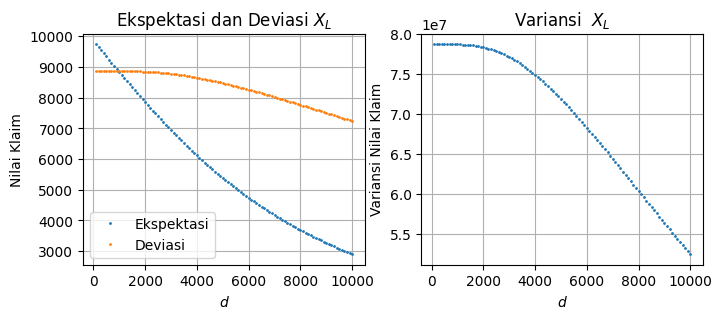

In [ ]:
# @title Ekspektasi dan Variansi Code
print(f'$E[X_L]$ = {Exp_deductible(2000)}')
print(f'$Var(X_L)^{0.5}$ = {Var_deductible(2000)**0.5}')
D = [100*i for i in range (1,101)]
ED = [Exp_deductible(d) for d in D]
DD = [(Var_deductible(d))**0.5 for d in D]
VD = [Var_deductible(d) for d in D]
fig, ax = plt.subplots(1,2,figsize=(8, 3))

ax[0].plot(D,ED,'.',markersize=2)
ax[0].plot(D,DD,'.', markersize=2)
ax[0].set_xlabel('$d$')
ax[0].set_ylabel('Nilai Klaim')
ax[0].set_title('Ekspektasi dan Deviasi $X_L$')
ax[0].legend(['Ekspektasi','Deviasi'])
ax[0].grid(True)

ax[1].plot(D,VD, '.', markersize=2)
ax[1].set_xlabel('$d$')
ax[1].set_ylabel('Variansi Nilai Klaim')
ax[1].set_title('Variansi  $X_L$')
ax[1].grid(True)

plt.show()

Dengan menggunakan *deductibel-2000*, ekspektasi dan variansinya mengecil. Ekspektasi dapat direduksi sekitar 2000 dolar dan standar deviasi direduksi sekitar 350 dolar. Jika diperhatikan dari gambar di atas, ekspektasi maupun variansi nya akan menurun seiring bertambahnya nilai $d$, tetapi penurunan standar deviasi tidak sesignifan penurunan ekspektasi. Jika ditinjau lebih lanjut, penurunan standar deviasi saat $d< 2000$ nilainya tidak signifikan kemudian saat $d> 2000$ penurunannya mulai signifikan. Sedangkan untuk penurunan ekspektasi, seiirng bertambahnya nilai $d$ penurunannya akan melandai.

### **A3. Fungsi Kuantil**

**Akan dicari fungsi kuantil dari $X_L$**

\begin{align}
\delta = P(X_L \le x_{\delta})
\end{align}
Perhatikan pada fungsi distribusi $X_L$, diperoleh $x_{\delta}=0$ untuk $\delta = \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg)$. Sedangkan untuk $\delta \in \bigg( \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg),1\bigg]$ diperoleh
\begin{align}
\delta &= \phi\bigg(\frac{ln(x_{\delta}+d)-\mu}{\sigma}\bigg) \\
\phi ^{-1} (\delta) & = \frac{ln(x_{\delta}+d)-\mu}{\sigma} \\
x_{\delta} & = exp(\mu-\sigma \phi^{-1}(\delta))-d
\end{align}
Sehingga diperoleh fungsi kuantil dari $X_L$ yaitu
\begin{align}
x_{\delta} =\begin{cases} 0 & ,0\le \delta \le \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg) \\ exp(\mu-\sigma \phi^{-1}(\delta))-d & , 1 \ge \delta > \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg) \\ Tidak \ ada & , \delta \ lainnya\end{cases}
\end{align}

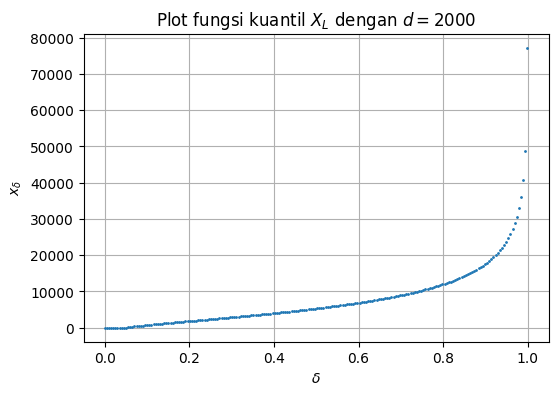

In [ ]:
delta = np.linspace(0,0.999,200)
Plot1(delta, q_L, 'fungsi kuantil', ['$\delta$','$x_{\delta}$'])

Perhatikan bahwa, saat $\delta$ mendekati 1, nilai kerugian akan semakin besar dan dari 200 sampel banyaknya kerugian dengan nilai tersebut akan semakin sedikit.

### **A4. Sampel Acak**

Ekspektasi: 7834.631826017943
Standar deviasi: 8643.81930776334


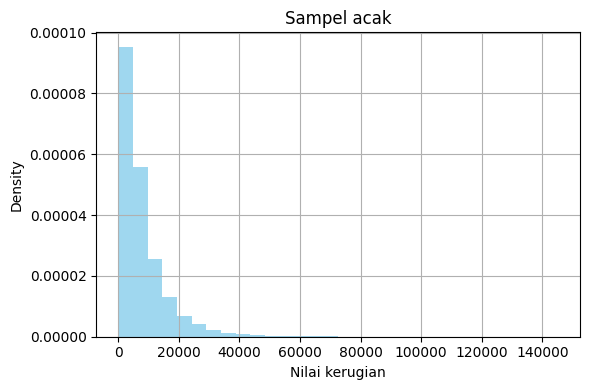

In [ ]:
X_L_acak = X_L(10000,2000)
print(f'Ekspektasi: {np.mean(X_L_acak)}')
print(f'Standar deviasi: {np.std(X_L_acak)}')
plt.figure(figsize=(6, 4))
plt.hist(X_L_acak, bins=30, density=True, alpha=0.8, color='skyblue', label='Data (Histogram)')
plt.xlabel('Nilai kerugian')
plt.ylabel('Density')
plt.title('Sampel acak')
plt.grid(True)
plt.tight_layout()
plt.show()

Mean dan standar deviasi dari sampel acak tidak jauh berbeda dengan hasil analitik. Distribusi yang diperoleh dari hasil deductibel seperti distribusi eksponensial.

## **B. Policy Limit**

Misalkan $X$ peubah acak kerugian yang sudah diperoleh sebelumnya. Kemudian $X_u$ merupakan peubah acak hasil modifikasi dari $X$ yang membatasi pembayaran kerugian sebesar $u$ jika kerugian yang ditimbulkan lebih dari sama dengan $u$ dan membayar kerugian sebesar kerugian tersebut jika kerugian lebih kecil dari $u$ secara matenatis
\begin{align}
X_u = X^{\text{^}}u= \begin{cases} X & , x < u \\ u & ,x\ge u\end{cases}
\end{align}

### **B1. Fungsi distribusi dan fungsi peluang**

**Akan dicari fungsi distribusi dari $X_u$**
\begin{align}
P(X_u \le x) &= P(X\le x\mid X< u)\cdot P(X < u)+P(u\le x\mid X\ge u)\cdot P(X\ge u) \\
&= P(X\le x)\cdot I_{x<u}+1\cdot I_{x>u}
\end{align}
Dengan $I_a$ merupakan fungsi karakteristik yang akan bernilai 1 jika $a$ benar. Karena $Y=ln(X) \sim normal (\mu,\sigma^2)$ maka
\begin{align}
P(X_u\le x) = \begin{cases}0 & , x < 0 \\ \phi\bigg(\frac{ln(x)-\mu}{\sigma}\bigg) &, x< u \\ 1 &, x\ge u \end{cases}
\end{align}
Kemudian untuk fungsi peluangnya yaitu
\begin{align}
f_{X_u}(x) = \begin{cases} f_X(x) &, 0 \le x< u \\ 1-\phi\bigg(\frac{ln(u)-\mu}{\sigma}\bigg) &, x= u \\ 0 &, x \ lainnya\end{cases}
\end{align}

In [ ]:
# @title Default title text
#Fungsi distribusi
def F_policylimit(x,u):
  if x<u:
    return phi((np.log(x)-mu)/s)
  else:
    return 1
# Ekspektasi dan Variansi
def EkXu(x,k):
  return np.exp(k*mu+k**2*s**2/2)*(phi((np.log(x)-mu-k*s**2)/s))+x**k*(1-phi((np.log(x)-mu)/s))
def Exp_policylimit(u):
  return EkXu(u,1)
def Var_policylimit(u):
  return EkXu(u,2)-EkXu(u,1)**2
# Fungsi kuantil dan membangkitkan sampel acak
def q_u(p,u):
  if p< phi((np.log(u)-mu)/s):
    return np.exp(mu+s*phi_inv(p))
  else:
    return u
def X_u(n,u):
  p = np.random.uniform(0,1,n)
  Xu = []
  for i in range(n):
    if p[i]<=phi((np.log(u)-mu)/s):
      Xu.append(np.exp(mu+s*phi_inv(p[i])))
    else:
      Xu.append(u)
  return np.array(Xu)

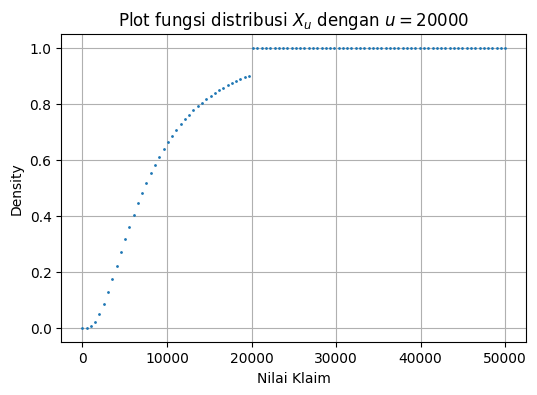

In [ ]:
x = np.linspace(0.001, 50000, 100)
Plot1(x,F_policylimit, 'fungsi distribusi', d=20000, con=1)

Berdasarkan fungsi distribusi dengan *policy limit* $u=20000$ dapat diperhatikan bahwa untuk $x \in (0,20000]$ maka fungsi distribusi mengikuti distribusi $X$ atau lognormal kemudian ada diskontinue saat nilai klaim bernilai $20000$.

### **B2. Ekspektasi dan variansi**

**Akan dicari ekspektasi dan variansi dari $X_u$**

Perhatikan bahwa
\begin{align}
E[(X_u)^k]&=E[X^k \mid X< u] \cdot P(X< u) + u^k\cdot P(X\ge u) \\
&= E[e^{kY} \mid X< u ] \cdot P(X < u) + u^k\cdot P(X\ge u) \\
&= \int_{\infty}^ {ln(u)} e^{ky}\cdot f_Y(y) dy+u^k\cdot P(X\ge u )\\
&= exp(k\mu+\frac{k^2\sigma^2}{2})\cdot \phi\bigg(\frac{ln(u)-\mu-k\sigma^2}{\sigma}\bigg)+u^k\cdot\bigg[ 1-\phi\bigg(\frac{ln(u)-\mu}{\sigma}\bigg)\bigg]
\end{align}
Sehngga dapat diperoleh $E[X_u]$ dan $E[(X_u)^2]$ kemudian diperoleh juga $Var(X_u)=E[(X_u)^2]-(E[X_u])^2$

$E[X_u]$ = 8841.830708526268
$Var(X_u)^0.5$ = 5615.98981739305


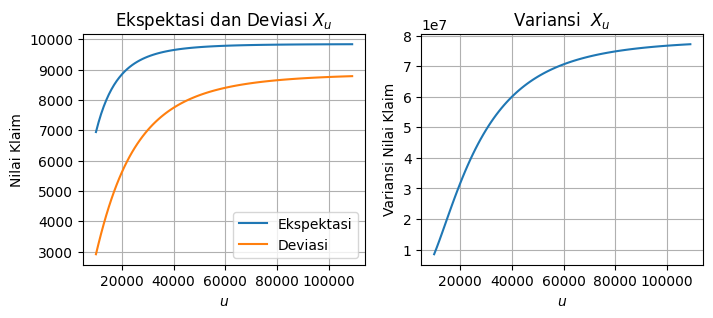

In [ ]:
# @title Default title text
print(f'$E[X_u]$ = {Exp_policylimit(20000)}')
print(f'$Var(X_u)^{0.5}$ = {Var_policylimit(20000)**0.5}')
D = [10000+1000*i for i in range (100)]
ED = [Exp_policylimit(d) for d in D]
DD = [(Var_policylimit(d))**0.5 for d in D]
VD = [Var_policylimit(d) for d in D]
fig, ax = plt.subplots(1,2,figsize=(8, 3))

ax[0].plot(D,ED)
ax[0].plot(D,DD)
ax[0].set_xlabel('$u$')
ax[0].set_ylabel('Nilai Klaim')
ax[0].set_title('Ekspektasi dan Deviasi $X_u$')
ax[0].legend(['Ekspektasi','Deviasi'])
ax[0].grid(True)

ax[1].plot(D,VD)
ax[1].set_xlabel('$u$')
ax[1].set_ylabel('Variansi Nilai Klaim')
ax[1].set_title('Variansi  $X_u$')
ax[1].grid(True)

plt.show()

Perhatikan bahwa ekspektasi dari nilai kerugian yang dikenai *policy limit* sebesar $20000$ memiliki ekspektasi yang lebih besar dibandingkan nilai kerugian yang dikenai *deductibel* $2000$. Sedangkan variansinya berbanding terbalik. Berdasarkan gambar di atas seiring bertambahnya nilai $u$ maka variansi dan ekspektasinya akan meningkat tetapi peningkatan tersebut memiliki limit tertentu. Hal ini karena distribusi $X$ memiliki ekor kanan yang terus mengecil.

**Akan dicari fungsi kuantil dari $X_u$**

Perhatikan fungsi distribusi untuk $X_u$, untuk $\delta \in [0,1)$ maka berlaku
\begin{align}
\delta &= P(X_u \le x_{\delta}) \\
&=\phi\bigg(\frac{ln(x_{\delta})-\mu}{\sigma}\bigg) \\
\phi^{-1}(\delta)&= \frac{ln(x_{\delta})-\mu}{\sigma} \\
x_{\delta} &=exp(\mu+\sigma \phi^{-1}(\delta))
\end{align}
Sedangkan untuk $\delta=1$ maka $x_{\delta}=u$. Diperoleh fungsi kuantil dari $X_u$ yaitu
\begin{align}
x_{\delta}=\begin{cases} exp(\mu+\sigma \phi^{-1}(\delta)) & , 0\le \delta< \phi\bigg(\frac{ln(u)-\mu}{\sigma}\bigg) \\ u & , \phi\bigg(\frac{ln(u)-\mu}{\sigma}\bigg)\le \delta \le 1 \\ Tidak \ ada & , \delta \ lainnya \end{cases}
\end{align}

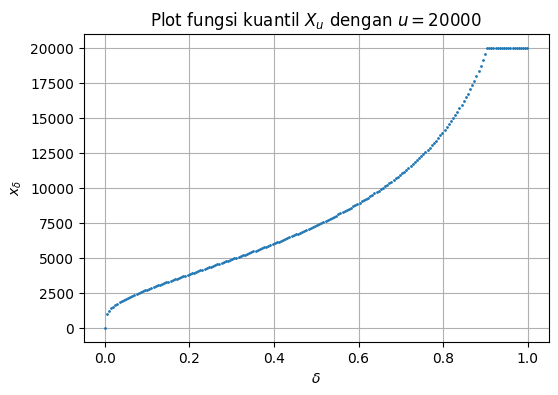

In [ ]:
delta = np.linspace(0,0.999,200)
Plot1(delta, q_u, 'fungsi kuantil', ['$\delta$','$x_{\delta}$'],d=20000, con=1)

Meskipun gambar dari fungsi kuantil merupakan inverse dari fungsi distribusi tetapi ada hal yang menarik dari plotnya. Bentuknya seperti sepatu jika dilihat dari samping. Nilai keruguan maksimal sebesar 20000 dan kerugian antara 15000 s.d 20000 cukup jarang terjadi.

### **B4. Sampel Acak**

Ekspektasi: 8953.780490771212
Standar deviasi: 5663.223524248308


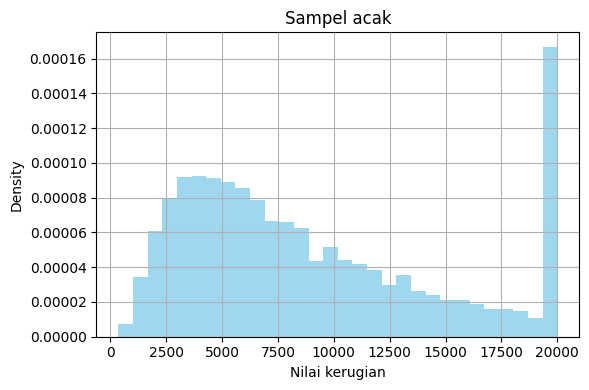

In [ ]:
# @title Default title text
X_u_acak = X_u(10000,20000)
print(f'Ekspektasi: {np.mean(X_u_acak)}')
print(f'Standar deviasi: {np.std(X_u_acak)}')
plt.figure(figsize=(6, 4))
plt.hist(X_u_acak, bins=30, density=True, alpha=0.8, color='skyblue', label='Data (Histogram)')
plt.xlabel('Nilai kerugian')
plt.ylabel('Density')
plt.title('Sampel acak')
plt.grid(True)
plt.tight_layout()
plt.show()

Perhatikan bahwa terjadinya kerugian sebesar 20000 merupakan nilai klaim dengan peluang terbesar. Sedangkan untuk nilai klaim kurang dari 20000 mengikuti distribusi lognormal terpancung di ujung kanan. Nilai ekspektasi dan variansi dari sampel acak yang dibangkitkan juga hampir sama seperti ekspektasi dan variansi hasil analitik.

## **C. *Deductabel-Policy Limit-Coinsurance***

Pada bagian ini, pemodelan tidak hanya menggunakan *coinsurance* tetapi juga menggunakan *deductible* dan *policy limit*. Perusahaan asuransi ingin membagi biaya klaim dengan pemegang polis sehingga perusahaan asuransi hanya menanggung kerugian sebesar $0< c < 1$ kali dan pemegang polis menanggung kerugian sebesar $1-c$. Misalkan juga, modifikasi *coinsurance* dikombinasikan dengan *deductible* dan *policy limit*. Sehingga modifikasi dari $X$ yaitu
\begin{align}
X_c = \begin{cases} 0 & , x\le d \\ c(X-d) & ,d< x < u \\ cu & , x\ge u\end{cases}
\end{align}

In [ ]:
# @title Default title text
#Fungsi distribusi
d,u = 2000, 20000
def F_coinsurance(x,c=0.8,d=2000, u=20000):
  if x==u:
    return phi((np.log(d)-mu)/s)
  elif 0<x<c*(u-d):
    return phi((np.log(d+x/c)-mu)/s)
  elif c*(u-d)<= x <c*u:
    return phi((np.log(u)-mu)/s)
  else:
    return 1
# Ekspektasi dan Variansi
def phiy(x):
  return phi((np.log(x)-mu)/s)
def Exp_coinsurance(c=0.8, d=2000, u=20000):
  return c*(Ek(d,1)-Ek(u,1))-c*d*(phiy(u)-phiy(d))+c*u*(1-phiy(u))
def Exp2_coinsurance(c=0.8, d=2000, u=20000):
  return c**2*(Ek(d,2)-Ek(u,2))-2*c*d*(Ek(d,1)-Ek(u,1)) + (c**2)*(d**2)*(phiy(u)-phiy(d))+(c**2)*(u**2)*(1-phiy(u))
def Var_coinsurance(c=0.8,d=2000, u=20000):
  return Exp2_coinsurance(c,d,u)-Exp_coinsurance(c,d,u)**2
# Fungsi kuantil dan membangkitkan sampel acak
def q_c(p,c=0.8,d=2000, u=20000):
  if p< phiy(d):
    return 0
  elif phiy(d) < p< phiy(u):
    return c*(np.exp(mu+s*phi_inv(p))-d)
  else:
    return c*u
def X_c(n,c=0.8):
  p = np.random.uniform(0,1,n)
  Xc = []
  for i in range(n):
    Xc.append(q_c(p[i],c))
  return np.array(Xc)

### **C1. Fungsi Distribusi**

**Akan dicari fungsi distribusi dari $X_c$**

\begin{align}
P(X_c \le x) &= P(X_c \le x \mid X\le d)P(X\le d)+P(X_c\le x\mid d < X < u)P(d< X< u)+ P(X_x\le x\mid X\ge u)P(X\ge u) \\
&= P(X\le d)+P(c(X-d)\le x\mid d < X < u)P(d < X < u)+P(X\ge u)
\end{align}
Perhatikan persamaan di atas, saat $X\le d$ maka $x=0$ dengan $P(X_c\le x)=P(X\le d)$. Kemudian saat $d< X < u$ maka $0< x < c(u-d)$ maka
\begin{align}
P(X_c \le x)&= P(X\le d)+ P(c(X-d)\le x, d < X < u) \\
&= P (X \le d)+P(X \le d+\frac{x}{c}, d < X < u) \\
&= P(X\le d) + P(d< X \le d +\frac{x}{c}) \\
&= P(X \le d + \frac{x}{c})
\end{align}

Karena $c< 1$ dan $u>d>0$ maka $cu> c(u-d)$. Fungsi distribusi untuk $c(u-d) \le x < cu$ yaitu $P(X_c \le x)=lim_{x \to c(u-d)} P(X\le d+\frac{x}{c})=P(X\le u)$

Kemudian saat $X\ge u$ maka $x=cu$ dengan $P(X_c \le x)=P(X\le u)+P(X\ge u)=1$. Dengan menggunakan $Y=ln(X)\sim normal(\mu, \sigma^2)$ diperoleh fungsi distribusi dari $X_c$ yaitu
\begin{align}
P(X_c\le x)=\begin{cases} \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg) & , x=0 \\
\phi\bigg(\frac{ln(d+\frac{x}{c})-\mu}{\sigma}\bigg) & , 0< x < c(u-d) \\
\phi\bigg(\frac{ln(u)-\mu}{\sigma}\bigg) & , c(u-d)\le x < cu \\ 1 &, x=cu \end{cases}
\end{align}
Fungsi peluang dari $X_c$ yaitu
\begin{align}
f_{X_c}(x)=\begin{cases} \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg) & , x=0 \\
\frac{1}{c}f_X(x)& , 0< x < c(u-d) \\
1-\phi\bigg(\frac{ln(u)-\mu}{\sigma}\bigg) & , x = cu \\ 0 &, x \ lainnya \end{cases}
\end{align}

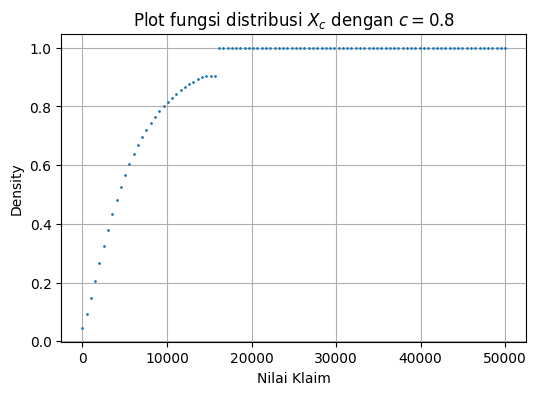

In [ ]:
x = np.linspace(0.001, 50000, 100)
Plot1(x,F_coinsurance, 'fungsi distribusi', d=0.8, con=2)

Berdasarkan gambar diatas nilai kerugian dari distribusi hasil modifikasi akan lebih kecil dari distribusi dasarnya (dlam kasus ini lognormal). Dengan adanya *coinsurance* $c$ dan *policy limit* $u$ maka kerugian maksimal yang mungkin diterima yaiut sebesar $cu$.

### **C2. Ekspektasi Dan Variansi**

**Akan dicari ekspektasi dan variansi dari $X_u$**

\begin{align}
E[X_c] &= E[c(X-d)\mid d < X < u]P(d < X < u)+cuP(X\ge u) \\
&= c\int_{ln(d)}^{ln(u)} e^yf_Y(y) dy-cdP(d< X < u)+cuP(X\ge u) \\
&= c\cdot exp(\mu +\frac{\sigma^2}{2})\int_{\frac{ln(d)-\mu-\sigma^2}{\sigma}}^{\frac{ln(u)-\mu-\sigma^2}{\sigma}} f_Z(z) dz-cdP(d< X < u)+cuP(X\ge u) \\
&= c\cdot exp(\mu+\frac{\sigma^2}{2})\bigg[\phi(\frac{ln(u)-\mu-\sigma^2}{\sigma})-\phi(\frac{ln(d)-\mu-\sigma^2}{\sigma})\bigg]-cd\bigg[\phi(\frac{ln(u)-\mu}{\sigma})-\phi(\frac{ln(d)-\mu}{\sigma})\bigg] \\ &+ cu\bigg[1-\phi(\frac{ln(u)-\mu}{\sigma})\bigg]
\end{align}

Momen kedua dari $X_c$ yaitu
\begin{align}
E[(X_c)^2]&= E[(c(X-d))^2\mid d < X < u]P(d < X < u)+c^2u^2P(X\ge u) \\
&= E[c^2X^2-2cdX+c^2d^2\mid d < X < u]P(d < X < u)+c^2u^2P(X\ge u) \\
&=c^2\cdot exp(2\mu+2\sigma^2)\bigg[\phi(\frac{ln(u)-\mu-2\sigma^2}{\sigma})-\phi(\frac{ln(d)-\mu-2\sigma^2}{\sigma})\bigg] \\ &-2cd\cdot exp(\mu+\frac{\sigma^2}{2})\bigg[\phi(\frac{ln(u)-\mu-\sigma^2}{\sigma})-\phi(\frac{ln(d)-\mu-\sigma^2}{\sigma})\bigg] \\ &+c^2d^2\bigg[\phi(\frac{ln(u)-\mu}{\sigma})-\phi(\frac{ln(d)-\mu}{\sigma})\bigg] + c^2u^2\bigg[1-\phi(\frac{ln(u)-\mu}{\sigma})\bigg]
\end{align}
Sehingga dapat diperoleh $var(X_c)=E[(X_c)^2]-(E[X_c])^2$

$E[X_c]$ = 5645.5313019578025
$Var(X_c)^0.5$ = 4306.525803074295


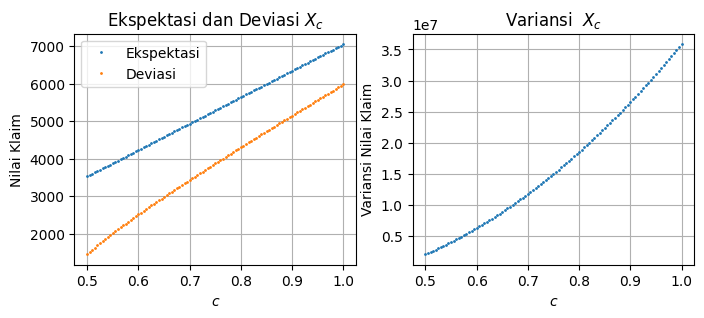

In [ ]:
# @title Default title text
print(f'$E[X_c]$ = {Exp_coinsurance(0.8)}')
print(f'$Var(X_c)^{0.5}$ = {Var_coinsurance(0.8)**0.5}')
D = [0.5+0.005*i for i in range (101)]
ED = [Exp_coinsurance(d) for d in D]
DD = [(Var_coinsurance(d))**0.5 for d in D]
VD = [Var_coinsurance(d) for d in D]
fig, ax = plt.subplots(1,2,figsize=(8, 3))

ax[0].plot(D,ED,'.',markersize=2)
ax[0].plot(D,DD,'.', markersize=2)
ax[0].set_xlabel('$c$')
ax[0].set_ylabel('Nilai Klaim')
ax[0].set_title('Ekspektasi dan Deviasi $X_c$')
ax[0].legend(['Ekspektasi','Deviasi'])
ax[0].grid(True)

ax[1].plot(D,VD, '.', markersize=2)
ax[1].set_xlabel('$c$')
ax[1].set_ylabel('Variansi Nilai Klaim')
ax[1].set_title('Variansi  $X_c$')
ax[1].grid(True)

plt.show()

Ekspektasi dan variansi pada distribusi yang dikenai *coinsurance* akan meningkat seiring bertambahnya nilai $c(< 1)$. Hasil modifikasi *deductible-policy limit-coinsurance* dengan $c=0.8$ beserta $d=2000$ dan $u=20000$, nilai ekspektasi dan variansinya dapat terpangkas hampir setengahnya dari distribusi asal.

### **C3. Fungsi Kuantil**

**Akan dicari fungsi kuantil dari $X_c$**

Perhatikan fungsi distribusi dari $X_c$, saat $\delta = \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg)$ maka $x_{\delta}=0$. kemudian saat $\delta \in (\phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg), \phi\bigg(\frac{ln(u)-\mu}{\sigma}\bigg))$ maka
\begin{align}
P(X_c\le x_{\delta})&=\delta \\
\phi\bigg(\frac{ln(d+\frac{x_{\delta}}{c})-\mu}{\sigma}\bigg) &=\delta \\
x_{\delta} &= c\cdot[ exp(\mu+\sigma\phi^{-1}(\delta))-d]
\end{align}
Selanjutnya untuk $\delta \in [\phi\bigg(\frac{ln(u)-\mu}{\sigma}\bigg),1]$ maka $x_{\delta}=cu$

Jadi fungsi kuantil dari $X_c$ yaitu
\begin{align}
x_{\delta}=\begin{cases}0 & , 0\le \delta \le \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg) \\ c\cdot [exp(\mu+\sigma\phi^{-1}(\delta))-d] &, \phi\bigg(\frac{ln(d)-\mu}{\sigma}\bigg) < \delta < \phi\bigg(\frac{ln(u)-\mu}{\sigma}\bigg) \\
cu &, \phi\bigg(\frac{ln(u)-\mu}{\sigma}\bigg)\le \delta \le 1 \\ Tidak \ ada &, \delta \ lainnya\end{cases}
\end{align}

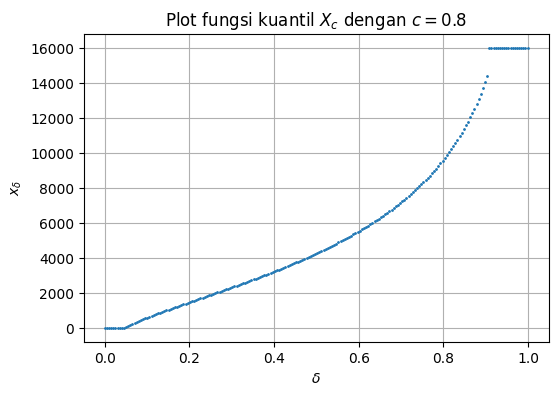

In [ ]:
delta = np.linspace(0,0.999,200)
Plot1(delta, q_c, 'fungsi kuantil', ['$\delta$','$x_{\delta}$'],d=0.8, con=2)

Berdasarkan plot fungsi kuantil, ternyata terdapat nilai klaim yang tidak mungkin ada, yaitu dari selang $c(u-d)$ s.d $cu$. Tentu, hal ini akan mengurangi kerugian agregat.

### **C4. Sampel Acak**

Ekspektasi: 5657.212245340233
Standar deviasi: 4792.451241759034


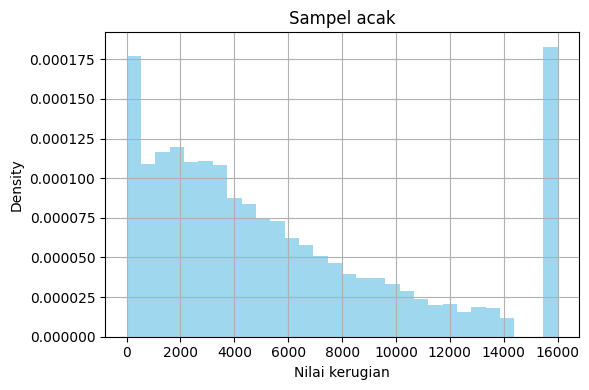

In [ ]:
# @title Default title text
X_c_acak = X_c(10000)
print(f'Ekspektasi: {np.mean(X_c_acak)}')
print(f'Standar deviasi: {np.std(X_c_acak)}')
plt.figure(figsize=(6, 4))
plt.hist(X_c_acak, bins=30, density=True, alpha=0.8, color='skyblue', label='Data (Histogram)')
plt.xlabel('Nilai kerugian')
plt.ylabel('Density')
plt.title('Sampel acak')
plt.grid(True)
plt.tight_layout()
plt.show()

mean dan standar deviasi dari sampel acak memiliki nilai yang hampir sama dengan ekspektasi dan variansi hasil analitik.

### **C5. Analisi *Coinsurance***

Berikut merupakan plot untuk kasus modifikasi *deductibel-policy limit-coinsurance* jika parameter $d, u$ dan $c$ sebagai variabel bebas.

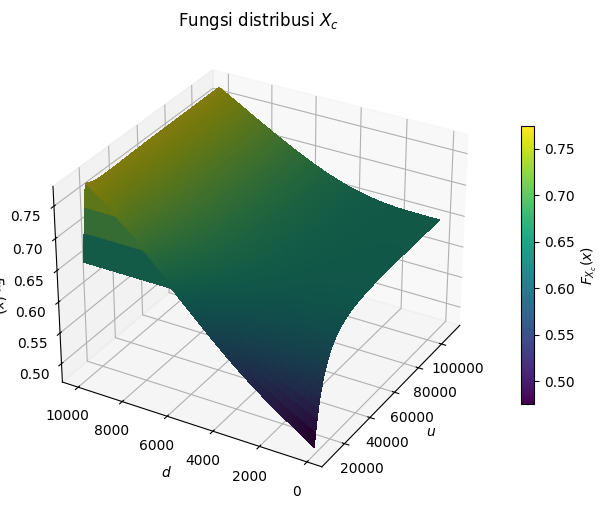

In [ ]:
# @title Fungsi distribusi
from matplotlib.cm import viridis
from matplotlib.colors import Normalize

# Buat grid untuk D dan U
U = [10000+1000*i for i in range (100)]
D = [100+100*i for i in range (100)]
D, U = np.meshgrid(D, U)

# Daftar nilai C
C_values = [0.5, 0.6, 0.7, 0.8 ,0.9]
U_flat = U.ravel()
D_flat = D.ravel()

Z_all = []
for C in C_values:
    X = np.vectorize(lambda d, u: Exp_coinsurance(c=C, d=d, u=u))(D, U)
    Z = np.vectorize(lambda x, d, u: F_coinsurance(x, c=C, d=d, u=u))(X, D, U)
    Z_all.append(Z)
Z_all = np.array(Z_all)
norm_color = Normalize(vmin=np.min(Z_all), vmax=np.max(Z_all))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=30, azim=210)

# Loop untuk setiap nilai C
for i, C in enumerate(C_values):
    Z = Z_all[i]
    colors = viridis(norm_color(Z))
    surf = ax.plot_surface(U, D, Z, facecolors=colors, rstride=1, cstride=1, alpha=0.8, linewidth=0, antialiased=False)

# Tambahkan colorbar dan label
mappable = plt.cm.ScalarMappable(cmap=viridis, norm=norm_color)
mappable.set_array(Z_all)
fig.colorbar(mappable, ax=ax, shrink=0.6, label='$F_{X_c}(x)$')

ax.set_xlabel('$u$')
ax.set_ylabel('$d$')
ax.set_zlabel('$F_{X_c}(x)$')
ax.set_title('Fungsi distribusi $X_c$')
plt.show()

Plot di atas yaitu nilai dari fungsi distribusi untuk $c=0.5, 0.6,0.7,0.8,0.9$ dengan $d$ dan $u$ seperti pada label grafik dan $x$ merupakan nilai ekspektasi untuk setiap $(d,u,c)$. Hasilnya cukup sulit dibedakan untuk setiap $c$

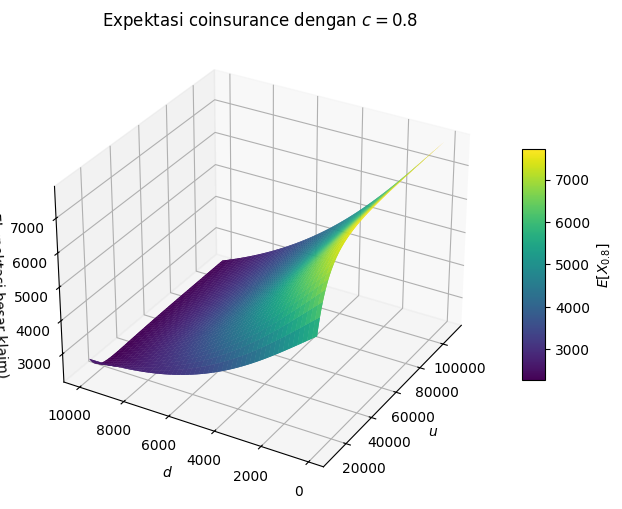

In [ ]:
# @title Default title text
from mpl_toolkits.mplot3d import Axes3D
U = [10000+1000*i for i in range (100)]
D = [100+100*i for i in range (100)]
U, D = np.meshgrid(U, D)
#Z = [Exp_coinsurance(d=d,u=u) for d,u in zip(D.ravel(),U.ravel())]
Z = [Exp_coinsurance(d=d,u=u) for d,u in zip(D.ravel(),U.ravel())]
Z = np.array(Z).reshape(U.shape)

# Membuat plot 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(U, D, Z, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='$E[X_{0.8}]$')
ax.view_init(elev=30, azim=210)

ax.plot_surface(U, D, Z, cmap='viridis')
ax.set_xlabel('$u$')
ax.set_ylabel('$d$')
ax.set_zlabel('Ekspektasi besar klaim)')
ax.set_title('Expektasi coinsurance dengan $c=0.8$')
plt.show()

Pda gambar di atas nilai ekspektasi dari modifikasi $c-0.8$ dengan nilai $(d,u)$ tertentu. Untuk $d$ dan $u$ besar ekspektasinya akan mengecil sedangkan untuk $u$ besar dan $x$ kecil ekspektasinya akan membesar.

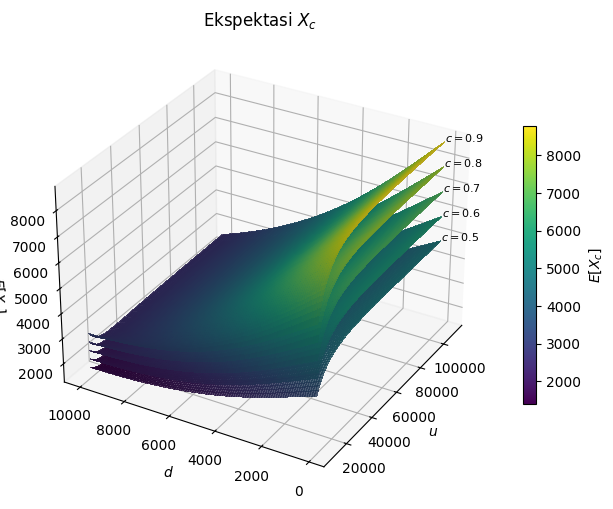

In [ ]:
# @title Ekspektasi
from matplotlib.cm import viridis
from matplotlib.colors import Normalize

# Buat grid untuk D dan U
U = [10000+1000*i for i in range (100)]
D = [100+100*i for i in range (100)]
D, U = np.meshgrid(D, U)

# Daftar nilai C
C_values = [0.5, 0.6, 0.7, 0.8,0.9]
U_flat = U.ravel()
D_flat = D.ravel()

Z_all = []
for C in C_values:
    Z = np.vectorize(lambda d, u: Exp_coinsurance(C, d, u))(D, U)
    Z_all.append(Z)
Z_all = np.array(Z_all)
norm_color = Normalize(vmin=np.min(Z_all), vmax=np.max(Z_all))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=30, azim=210)

# Loop untuk setiap nilai C
for i, C in enumerate(C_values):
    Z = Z_all[i]
    colors = viridis(norm_color(Z))
    surf = ax.plot_surface(U, D, Z, facecolors=colors, rstride=1, cstride=1, alpha=0.8, linewidth=0, antialiased=False)

    # Tambahkan anotasi nilai C langsung di plot
    i_dmax = -1
    j_umin = 0
    z_val = Z[i_dmax, j_umin]
    u_val = U[i_dmax, j_umin]
    d_val = D[i_dmax, j_umin]

    ax.text(u_val, d_val, z_val,
            f'$c={C}$', color='black', fontsize=8)

# Tambahkan colorbar dan label
mappable = plt.cm.ScalarMappable(cmap=viridis, norm=norm_color)
mappable.set_array(Z_all)
fig.colorbar(mappable, ax=ax, shrink=0.6, label='$E[X_c]$')

ax.set_xlabel('$u$')
ax.set_ylabel('$d$')
ax.set_zlabel('$E[X_c]$')
ax.set_title('Ekspektasi $X_c$')
plt.show()


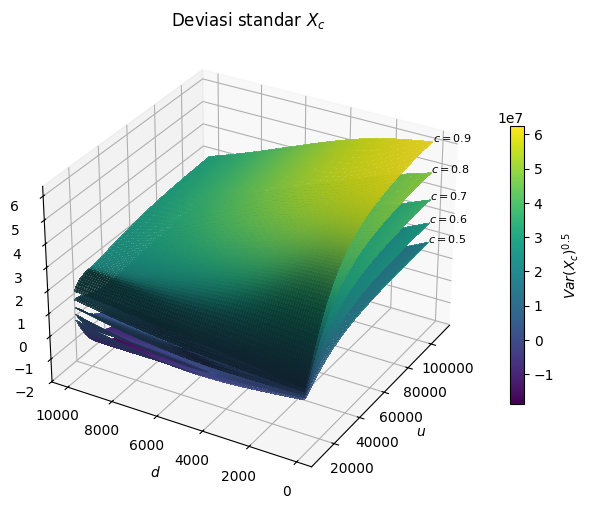

In [ ]:
# @title Deviasi Standar
from matplotlib.cm import viridis
from matplotlib.colors import Normalize

# Buat grid untuk D dan U
U = [10000+1000*i for i in range (100)]
D = [100+100*i for i in range (100)]
D, U = np.meshgrid(D, U)

# Daftar nilai C
C_values = [0.5, 0.6, 0.7, 0.8,0.9]
U_flat = U.ravel()
D_flat = D.ravel()

Z_all = []
for C in C_values:
    Z = np.vectorize(lambda d, u: Var_coinsurance(c=C, d=d, u=u))(D, U)
    Z_all.append(Z)
Z_all = np.array(Z_all)
norm_color = Normalize(vmin=np.min(Z_all), vmax=np.max(Z_all))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=30, azim=210)

# Loop untuk setiap nilai C
for i, C in enumerate(C_values):
    Z = Z_all[i]
    colors = viridis(norm_color(Z))
    surf = ax.plot_surface(U, D, Z, facecolors=colors, rstride=1, cstride=1, alpha=0.8, linewidth=0, antialiased=False)

    # Tambahkan anotasi nilai C langsung di plot
    i_dmax = -1
    j_umin = 0
    z_val = Z[i_dmax, j_umin]
    u_val = U[i_dmax, j_umin]
    d_val = D[i_dmax, j_umin]

    ax.text(u_val, d_val, z_val,
            f'$c={C}$', color='black', fontsize=8)

# Tambahkan colorbar dan label
mappable = plt.cm.ScalarMappable(cmap=viridis, norm=norm_color)
mappable.set_array(Z_all)
fig.colorbar(mappable, ax=ax, shrink=0.6, label='$Var(X_c)^{0.5}$')

ax.set_xlabel('$u$')
ax.set_ylabel('$d$')
ax.set_zlabel('$Var(X_c)^{0.5}$')
ax.set_title('Deviasi standar $X_c$')
plt.show()

In [ ]:
for i in range (len(C_values)):
  if len(Z_all[i][Z_all[i]<0]):
    print(f'c={C_values[i]}')

c=0.5
c=0.6
c=0.7


Momen pusat kedua tidak mungkin bernilai negatif. Namun, pada perhitungan ini diperoleh nilai negatif saat $c$ bernilai $0.5, 0.6$ dan $0.7$. Hal ini disebabkan oleh error karena pemenggalan desimal pada komputasi. Pada saat $c$ bernilai kecil maka nilai momen kedua dan pertama akan cukup dekat sehingga memungkinkan adanya error pemenggalan desimal. Penulis menduga error ini disebabkan oleh pemenggalan desimal pada modul `norm` yang digunakan. Karena perhitungan pada modul tersebut dilakukan secara numerik. Tentu, perlu adanya investigasi lebih lanjut tetapi karena keterbatasan waktu, hal tersebut belum sempat dilakukan. Dari hasil ini, bisa menjadi *warning* bagi penulis pribadi saat menggunakan modul yang ada karena memungkinkan dapat menyebabkan bias dalam komputasi.

# **3. Simpulan**

Ada beberapa *insight* yang penulis peroleh saat mendalami modifikasi distribusi kerugian. Tujuan modifikasi yaitu untuk mengurangi agregat kerugian dengan kata lain bisa menekan lagi besar premi yang akan ditanggungkan pada pemegang polis sehingga produk asuransi yang ditawarkan akan lebih menarik atau untuk memperbesar keuntungan bagi perusahaan asuransi.

- Jika menggunakan *deductibel* memang mean kerugian akan lebih kecil tetapi pengurangan variabilitasnya tidak terlalu signifikan. Produknya menjadi lebih menarik tetapi juga ketidakpastiannya menjadi lebih besar. Hal ini disebabkan oleh kerugian yang dapat diterima oleh perusahaan tidak terbatas.Oleh karena itu, perlu berhati-hati jika menggunakan modifikasi ini. Produk asuransi  ini cocok untuk dipasarkan ke *kelompok masyarakat menengah*

- Jika menggunakan *policy limit* variabilitasnya dapat dikurangi cukup signifikan tetapi mean kerugain yang diterima masih cukup besar. Hal ini berdampak pada produk yang kita tawarkan jadi tidak menarik meskipun ketidakpastiannya lebih kecil. Hal ini disebabkan oleh besar kerugian yang dibayarkan perusahaan hanya sebesar $u$ yang berhingga. Pemegang polis dengan risiko yang tak berhingga kemungkinan enggan untuk memilih produk ini. Produk ini cocok dipasarkan untuk *kelompok masyarakat* atas dengan pemilihan nilai $u$ yang tepat.

- Jika menggunakan *coinsurance* saja mean dan variabilitasnya bisa ditekan tetapi nilai kerugiannya juga tidak terbatas. Karena hanya sebesar $1-c$ kerugian yang dialokasikan ke pihak tertanggung.

- Jika menggunakan *deductibel-policy limit-coinsurance*, mean dan variabilitas dari kerugian yang diterima oleh perusahaan asuransi akan lebih kecil. Sehingga produk asuransi yang ditawarkan akan lebih menarik dan ketidakpastiannya lebih kecil. Hal ini dikarenakan kerugian yang diterima oleh perusahaan asuransi berhingga sebesar $cu$. Tentu pemilihan parameter $u,d$ dan $c$ yang optimal menjadi tantangan tersendiri agar produk asuransi yang diterbitkan mampu menarik polis dan keuntungan bagi perusahaan. Perlu dicatat juga, klausul pada produk asuransi ini juga cukup kompleks. Sehingga perlu dilakukan penjelasan yang detil ketika menawarkan produk ini. Hal ini perlu dilakukan agar *nama baik* perusahaan tetap terjaga.

In [ ]:
print('EndCode')

EndCode


In [ ]:
print('End Code')

End Code


In [ ]:
print('EndCode')

EndCode


End of code

End Code